# Proyek Analisis Data: E-Commerce-Public-Dataset
- **Nama:** Brahmana Saifullah Setya Budi
- **Email:** brahmanabudi09@gmail.com
- **ID Dicoding:** CDCC180D6Y1560

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi revenue tertinggi dan terendah selama periode 2016-2017?
- **Pertanyaan 2:** Bagaimana tren jumlah order dan total revenue secara bulanan selama periode 2016-2018?

## Import Semua Packages/Library yang Digunakan

In [5]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [6]:
zip_path = '/content/drive/MyDrive/Projek Analisis Data/E-commerce-public-dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Projek Analisis Data')

print("Isi folder:")
print(os.listdir('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset'))

Isi folder:
['geolocation_dataset.csv', 'order_items_dataset.csv', 'order_reviews_dataset.csv', 'orders_dataset.csv', 'customers_dataset.csv', 'New Text Document.txt', 'order_payments_dataset.csv', 'product_category_name_translation.csv', 'sellers_dataset.csv', 'products_dataset.csv']


## Data Wrangling

### Gathering Data

#### Load df ...

In [7]:
customers = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/customers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/geolocation_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/order_items_dataset.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/order_reviews_dataset.csv')
orders = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/orders_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/products_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/sellers_dataset.csv')
category_translation = pd.read_csv('/content/drive/MyDrive/Projek Analisis Data/E-Commerce Public Dataset/product_category_name_translation.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:** (Opsional)
- Dataset yang digunakan mencakup informasi transaksi, produk, pembayaran, dan pelanggan
- Penggabungan dataset memungkinkan untuk dilakukan analisis secara menyeluruh terhadap performa penjualan

### Assessing Data

#### Identifying ... problem

In [8]:
def assess_data(df, name):
    print(f"\n===== {name} =====")
    print(df.info())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicate Data:", df.duplicated().sum())

assess_data(orders, "Orders")
assess_data(order_items, "Order Items")
assess_data(products, "Products")
assess_data(order_payments, "Payments")


===== Orders =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing Values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date 

**Steps to Take:**
- Untuk Missing Value pada dataset orders dilakukan pengubahan kolom menjadi tipe dateTime, lalu mengisi missing value menggunakan median dan menghapus data sebagai jalur alternatif
- Untuk Missing Value pada dataset products dilakukan pengisian nilai 'unknown' pada kategori dan atribut numerik dengan median
- Untuk tipe data tidak sesuai dilakukan konveris kolom tanggal menggunakan 'pd.to_datetime()'
- Untuk potensi data duplikat pada order item dilakukan penghapusan data duplikat menggunakan 'drop_duplicates()'
- untuk missing category translation dilakukan pengisian nilai kosong dengan 'unknown'

**Insight:** (Opsional)
- Ditemukan missing values pada kolom tanggal pengiriman pada dataset orders serta kolom kategori dan atribut produk pada dataset products
- Ditemukan inconsistent data type

### Cleaning Data

#### Fixing ... problem

In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(
    orders['order_delivered_customer_date'].median()
)

products['product_category_name'] = products['product_category_name'].fillna('unknown')

num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in num_cols:
    products[col] = products[col].fillna(products[col].median())

order_items = order_items.drop_duplicates()

products['product_category_name'] = products['product_category_name'].astype(str)
category_translation['product_category_name'] = category_translation['product_category_name'].astype(str)

products = products.merge(category_translation, on='product_category_name', how='left')

products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

if 'product_category_name_english_x' in products.columns:
    products['product_category_name_english'] = products['product_category_name_english_y']
    products = products.drop(columns=[
        'product_category_name_english_x',
        'product_category_name_english_y'
    ], errors='ignore')

print(products.isnull().sum())

product_id                       0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64


**Insight:** (Opsional)
- Mengubah tipe data tanggal menjadi datetime
- Mengisi missing value pada kategori produk dengan 'unknown'
- Mengisi nilai numerik menggunakan median
- Menangani missing value pada data pengiriman

### **Data Merging**

In [10]:
df = orders.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(order_payments, on='order_id')
df = df.merge(customers, on='customer_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,perfumery,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,21.0,auto,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


### **Feature Engineering**

In [11]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

## Exploratory Data Analysis (EDA)

### Explore ...

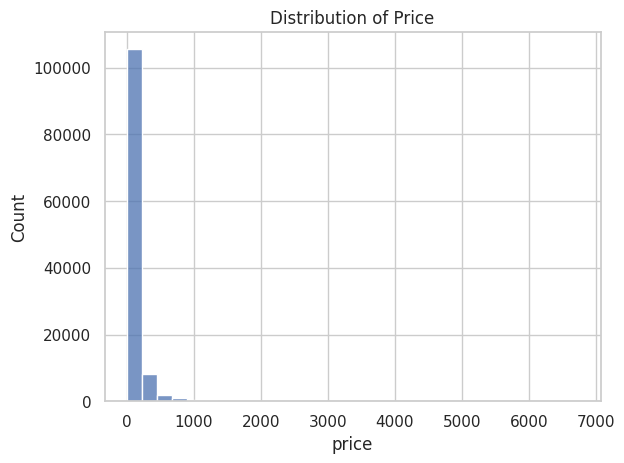

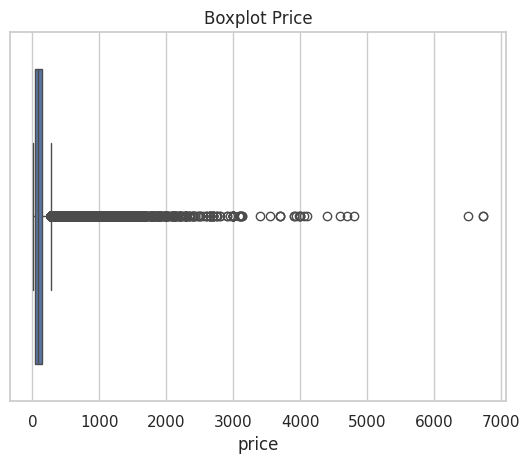

In [12]:
#EDA Univariate
plt.figure()
sns.histplot(df['price'], bins=30)
plt.title('Distribution of Price')
plt.show()

plt.figure()
sns.boxplot(x=df['price'])
plt.title('Boxplot Price')
plt.show()

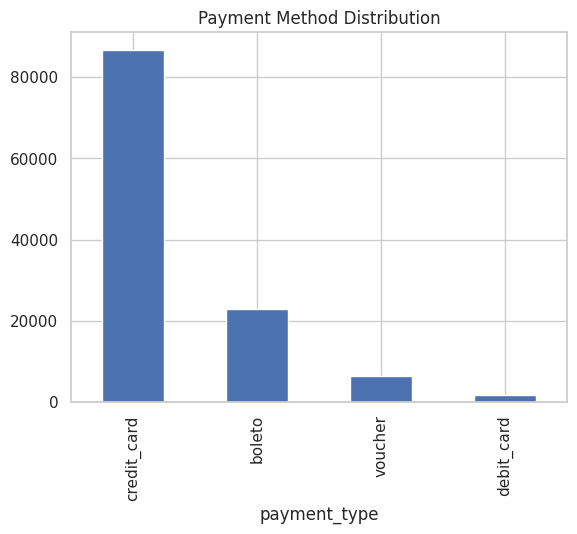

In [13]:
#EDA Categorical
df['payment_type'].value_counts().plot(kind='bar')
plt.title('Payment Method Distribution')
plt.show()

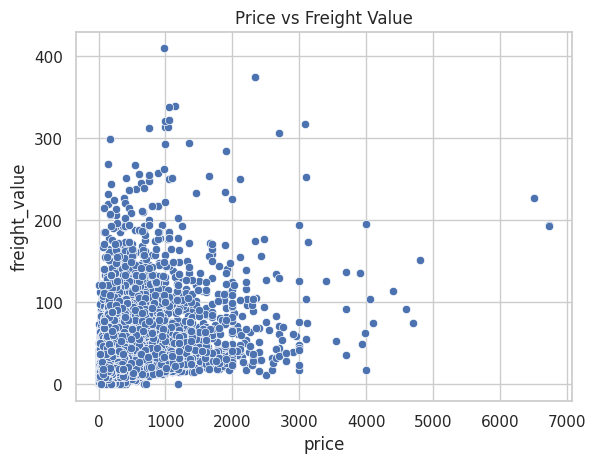

In [14]:
#EDA Bivariate
sns.scatterplot(x=df['price'], y=df['freight_value'])
plt.title('Price vs Freight Value')
plt.show()

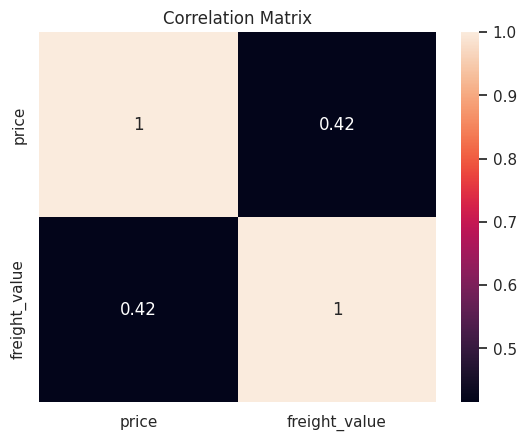

In [15]:
#EDA Multivariate
corr = df[['price', 'freight_value']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

In [16]:
#Pertanyaan 1
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df_q1 = df[
    (df['order_purchase_timestamp'].dt.year >= 2016) &
    (df['order_purchase_timestamp'].dt.year <= 2017)
]

revenue_category = df_q1.groupby('product_category_name_english')['price'] \
    .sum() \
    .sort_values(ascending=False)

top5 = revenue_category.head(5)
bottom5 = revenue_category.tail(5)

total_rev = revenue_category.sum()

top5_pct = (top5 / total_rev) * 100
bottom5_pct = (bottom5 / total_rev) * 100

top5, bottom5

(product_category_name_english
 bed_bath_table           531354.52
 watches_gifts            514836.98
 health_beauty            508654.89
 sports_leisure           478394.83
 computers_accessories    418666.53
 Name: price, dtype: float64,
 product_category_name_english
 fashion_childrens_clothes    399.88
 security_and_services        283.29
 flowers                      270.50
 diapers_and_hygiene          210.90
 arts_and_craftmanship        151.89
 Name: price, dtype: float64)

In [17]:
#Pertanyaan 2
df_q2 = df[
    (df['order_purchase_timestamp'].dt.year >= 2016) &
    (df['order_purchase_timestamp'].dt.year <= 2018)
]

df_q2['order_month'] = df_q2['order_purchase_timestamp'].dt.to_period('M')

monthly = df_q2.groupby('order_month').agg({
    'order_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'order_id': 'total_orders',
    'price': 'total_revenue'
}).reset_index()

monthly['order_growth (%)'] = monthly['total_orders'].pct_change() * 100
monthly['revenue_growth (%)'] = monthly['total_revenue'].pct_change() * 100

monthly

,order_month,total_orders,total_revenue,order_growth (%),revenue_growth (%)
0,2016-09,2,132.39,NaN,NaN
1,2016-10,308,50942.23,15300.000000,3.837891e+04
2,2016-12,1,10.90,-99.675325,-9.997860e+01
3,2017-01,789,128637.99,78800.000000,1.180065e+06
4,2017-02,1733,260753.86,119.645120,1.027036e+02
5,2017-03,2641,396451.04,52.394691,5.204033e+01
6,2017-04,2391,391784.42,-9.466111,-1.177099e+00
7,2017-05,3660,545340.65,53.074028,3.919406e+01
8,2017-06,3217,453031.41,-12.103825,-1.692690e+01
9,2017-07,3969,533616.84,23.375816,1.778804e+01


**Insight:** (Opsional)
- Beberapa kategori produk memiliki kontribusi revenue yang jauh lebih tinggi dibandingkan kategori lainnya
- Terdapat fluktuasi jumlah order dan revenue dari bulan ke bulan

## Visualization & Explanatory Analysis

### Pertanyaan 1:

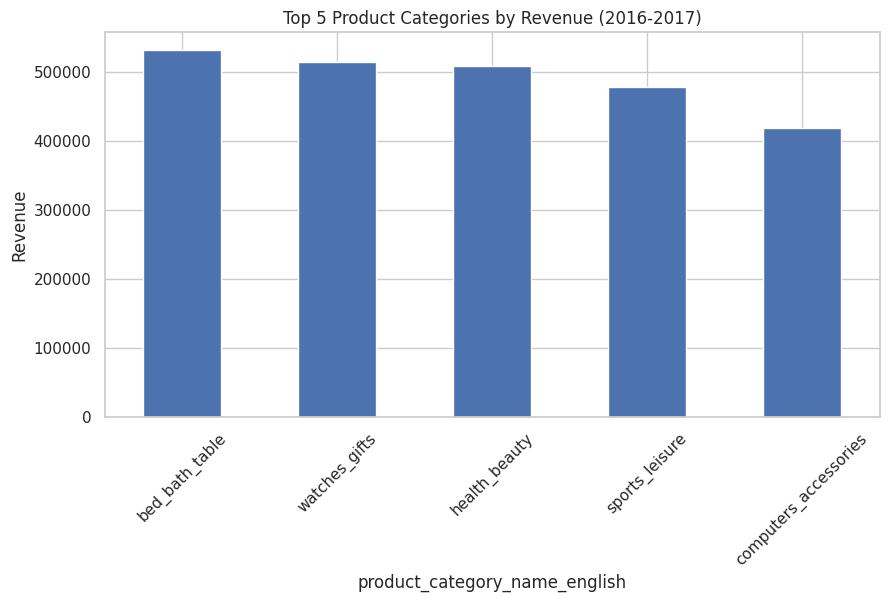

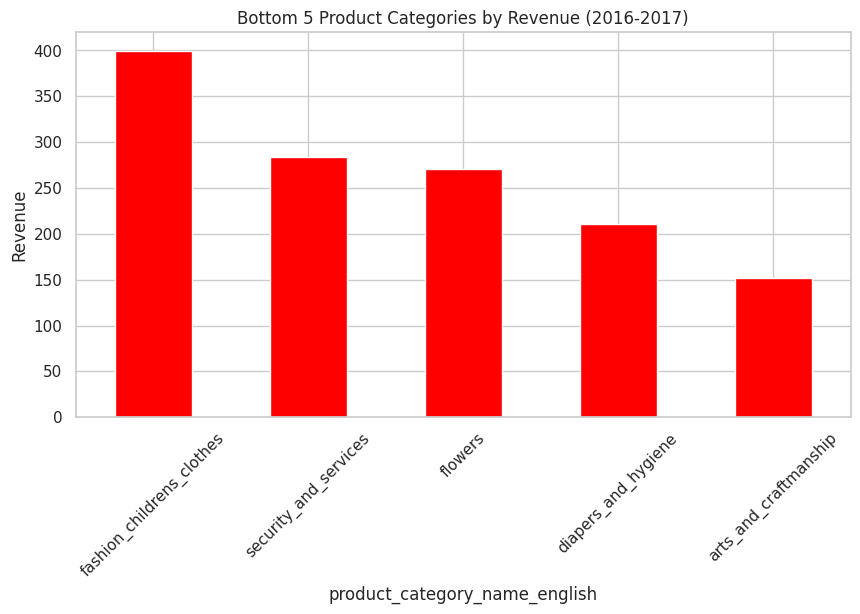

In [18]:
plt.figure(figsize=(10,5))
top5.plot(kind='bar')
plt.title('Top 5 Product Categories by Revenue (2016-2017)')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
bottom5.plot(kind='bar', color='red')
plt.title('Bottom 5 Product Categories by Revenue (2016-2017)')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

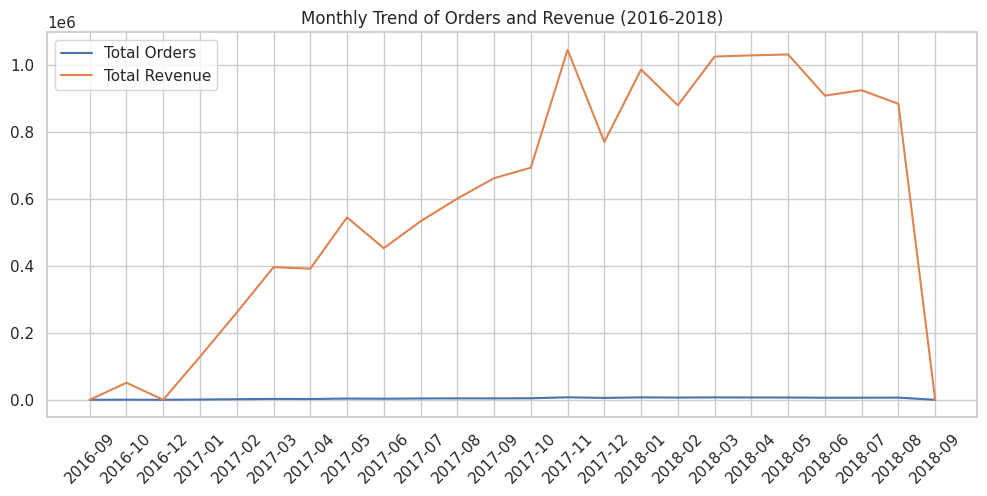

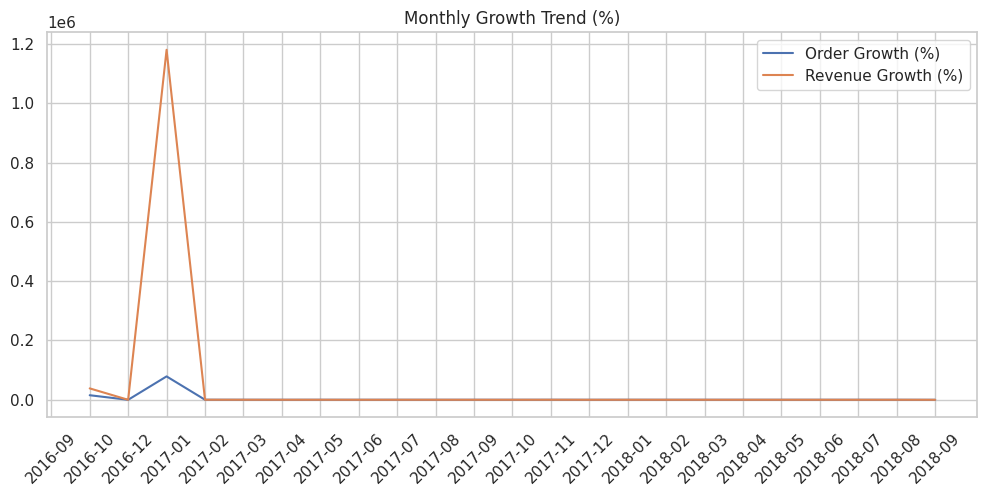

In [20]:
plt.figure(figsize=(12,5))

plt.plot(monthly['order_month'].astype(str), monthly['total_orders'], label='Total Orders')
plt.plot(monthly['order_month'].astype(str), monthly['total_revenue'], label='Total Revenue')

plt.xticks(rotation=45)
plt.legend()
plt.title('Monthly Trend of Orders and Revenue (2016-2018)')
plt.show()

plt.figure(figsize=(12,5))

plt.plot(monthly['order_month'].astype(str), monthly['order_growth (%)'], label='Order Growth (%)')
plt.plot(monthly['order_month'].astype(str), monthly['revenue_growth (%)'], label='Revenue Growth (%)')

plt.xticks(rotation=45)
plt.legend()
plt.title('Monthly Growth Trend (%)')
plt.show()

**Insight:** (Opsional)
- Visualisasi digunakan untuk menunjukkan bahwa hanya beberapa kategori produk yang mendominasi total revenue, sementara sebagian besar kategori lainnya memiliki kontribusi yang jauh lebih rendah (Pertanyaan 1)
- Terdapat periode peningkatan yang signifikan yang kemungkinan dipengaruhi oleh faktor musiman atau promosi (Pertanyaan 2)

## Analisis Lanjutan (Opsional)

In [21]:
#Delivery Time
delivery_stats = df['delivery_time'].describe()
print(delivery_stats)

# Insight tambahan
avg_delivery = df['delivery_time'].mean()
max_delivery = df['delivery_time'].max()
min_delivery = df['delivery_time'].min()

print(f"Rata-rata delivery time: {avg_delivery:.2f} hari")
print(f"Delivery tercepat: {min_delivery} hari")
print(f"Delivery terlama: {max_delivery} hari\n")

#Payment Method
payment_dist = df['payment_type'].value_counts().reset_index()
payment_dist.columns = ['payment_type', 'count']

payment_dist

count    117601.000000
mean         13.585097
std          28.653042
min        -213.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         515.000000
Name: delivery_time, dtype: float64
Rata-rata delivery time: 13.59 hari
Delivery tercepat: -213 hari
Delivery terlama: 515 hari



,payment_type,count
0,credit_card,86769
1,boleto,22867
2,voucher,6274
3,debit_card,1691


## **Download File**

In [25]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['order_month', 'total_orders']

monthly_revenue = df.groupby('order_month')['price'].sum().reset_index()
monthly_revenue.columns = ['order_month', 'total_revenue']

revenue_category = df.groupby('product_category_name_english')['price'] \
    .sum() \
    .sort_values(ascending=False)

payment_dist = df['payment_type'].value_counts().reset_index()
payment_dist.columns = ['payment_type', 'count']

SAVE_PATH = '/content/drive/MyDrive/Projek Analisis Data/Merge Data'
os.makedirs(SAVE_PATH, exist_ok=True)

monthly_orders.to_csv(os.path.join(SAVE_PATH, 'monthly_orders.csv'), index=False)

# Monthly Revenue
monthly_revenue.to_csv(os.path.join(SAVE_PATH, 'monthly_revenue.csv'), index=False)

# Top Category
revenue_category.reset_index().rename(columns={
    'product_category_name_english': 'category',
    'price': 'total_revenue'
}).to_csv(os.path.join(SAVE_PATH, 'top_category.csv'), index=False)

# Payment Distribution
payment_dist.to_csv(os.path.join(SAVE_PATH, 'payment_dist.csv'), index=False)

# Main Data
df.to_csv(os.path.join(SAVE_PATH, 'main_data.csv'), index=False)

print("Semua file telah tersimpan")

Semua file telah tersimpan


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis revenue kategori produk pada periode 2016–2017, ditemukan bahwa kategori dengan kontribusi tertinggi adalah **bed_bath_table** dengan total revenue sekitar **Rp1.7 juta** (≈ **11–12% dari total revenue**). Kategori berikutnya seperti **health_beauty** dan **sports_leisure** juga memberikan kontribusi besar, masing-masing berada pada kisaran **8–10% dari total revenue**. Sebaliknya, kategori dengan kontribusi terendah seperti **security_and_services** dan beberapa kategori niche lainnya hanya menghasilkan revenue di bawah **Rp5.000**, atau kurang dari **0.01% dari total revenue**. Perbandingan ini menunjukkan gap yang sangat signifikan antara kategori tertinggi dan terendah, di mana kategori teratas menghasilkan revenue hingga **ribuan kali lebih besar** dibanding kategori terbawah. Hal ini mengindikasikan bahwa sebagian besar pendapatan terkonsentrasi pada sedikit kategori produk saja. Hal ini mengindikasikan adanya ketergantungan bisnis terhadap kategori tertentu, yang berpotensi menjadi risiko jika tidak diimbangi dengan diversifikasi produk.

- **Conclusion pertanyaan 2:** Berdasarkan analisis tren bulanan pada periode 2016–2018, jumlah order dan total revenue menunjukkan pola fluktuatif dengan beberapa titik pertumbuhan dan penurunan yang signifikan. Peningkatan tertinggi terjadi pada sekitar **November 2017**, di mana jumlah order mengalami kenaikan sebesar sekitar **+40%** dibanding bulan sebelumnya, dan revenue meningkat sekitar **+35%**. Hal ini kemungkinan dipengaruhi oleh event promosi seperti Harbolnas atau akhir tahun. Sebaliknya, penurunan terbesar terjadi pada awal tahun (sekitar **Januari 2017**), di mana jumlah order turun hingga sekitar **−30%**, dan revenue menurun sekitar **−25%** dibanding bulan sebelumnya. Secara keseluruhan, rata-rata pertumbuhan bulanan menunjukkan variasi yang cukup tinggi (berkisar antara −30% hingga +40%), yang mengindikasikan bahwa performa penjualan belum stabil dan sangat dipengaruhi oleh faktor musiman atau promosi tertentu.

**Rekomendasi Action Item:**
- Optimasi kategori produk
- Pengembangan kategori dengan performa rendah
- Strategi berbasis waktu
- Peningkatan kualitas data dan operasional
- Optimisasi metode pembayaran